# Safe-to-Play: Athlete Injury Risk Prediction

**Group:** TXC-AS  
**Course:** Machine Learning 2026  
**Dataset:** High Accuracy Sport Injury Dataset (600 athletes)

---

> **Business Context:**  
> As the Performance Analytics department of a professional football club, our goal is to build a binary classification model: the *Safe-to-Play* classifier. It predicts injury risk based on physiological markers and training workload to support coaching staff in making data-driven decisions about player readiness.

# 1. Setup & Data Loading

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
import xgboost as xgb
import shap

# Global plot settings
mpl.rc('axes',  labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
sns.set_style('whitegrid')

RANDOM_STATE = 42  # fixed seed for reproducibility across all models and splits

# Feature-group colour palette (consistent throughout the notebook)
COLOR_BIO       = '#4C72B0'  # blue, biological markers
COLOR_LOAD      = '#DD8452'  # orange, training load
COLOR_RECOVERY  = '#55A868'  # green, recovery & lifestyle
COLOR_CONDITION = '#8172B2'  # purple, physical condition
COLOR_TARGET    = ['#2196F3', '#E53935']  # blue = no risk, red = at risk

print("Libraries loaded.")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries loaded.


## 1.1 Data Loading

In [2]:
df = pd.read_excel('../data/High_Accuracy_Sport_Injury_Dataset.xlsx')
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Training_Frequency,Training_Duration,Warmup_Time,Sleep_Hours,Flexibility_Score,Muscle_Asymmetry,Recovery_Time,Injury_History,Stress_Level,Training_Intensity,Injury_Risk
0,36,0,155.4,56.3,23.34,1,94,20,7.2,63.3,3.7,63,1,8,4.4,0
1,30,0,167.6,45.3,16.12,4,114,5,7.1,64.6,5.1,64,1,7,6.7,0
2,21,1,176.7,60.8,19.48,1,95,11,5.0,68.6,6.1,69,0,6,4.3,1
3,37,0,170.2,60.7,20.97,5,73,6,8.1,69.0,4.6,65,2,3,6.4,1
4,30,0,161.5,45.0,17.25,6,93,8,7.8,45.2,8.5,42,3,8,4.2,1


## 1.2 First Look

In [3]:
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

target_dist = pd.DataFrame({
    'Count': df['Injury_Risk'].value_counts(),
    '%': df['Injury_Risk'].value_counts(normalize=True).mul(100).round(1)
})
print(f"\nTarget distribution:\n{target_dist}")

Shape: (600, 16)

Data types:
Age                     int64
Gender                  int64
Height_cm             float64
Weight_kg             float64
BMI                   float64
Training_Frequency      int64
Training_Duration       int64
Warmup_Time             int64
Sleep_Hours           float64
Flexibility_Score     float64
Muscle_Asymmetry      float64
Recovery_Time           int64
Injury_History          int64
Stress_Level            int64
Training_Intensity    float64
Injury_Risk             int64
dtype: object

Missing values:
Age                   0
Gender                0
Height_cm             0
Weight_kg             0
BMI                   0
Training_Frequency    0
Training_Duration     0
Warmup_Time           0
Sleep_Hours           0
Flexibility_Score     0
Muscle_Asymmetry      0
Recovery_Time         0
Injury_History        0
Stress_Level          0
Training_Intensity    0
Injury_Risk           0
dtype: int64

Target distribution:
             Count     %
Injury_Risk    

**First look summary:**
- All 16 features are numeric (int64 / float64), so no encoding is needed for most variables
- No missing values across all 600 records. The dataset is clean and ready to use
- The target is imbalanced: **68.5% safe (0)** vs **31.5% at risk (1)**. We will account for this during modelling with stratified splits and class weighting

# 2. Exploratory Data Analysis

The EDA is structured to directly inform feature engineering decisions. We start with a full correlation overview, then dive into each feature group, and finish with cross-group interactions and a summary of what we take into Section 3.

## 2.1 Correlation with Target

Which features have the strongest relationship with injury risk?

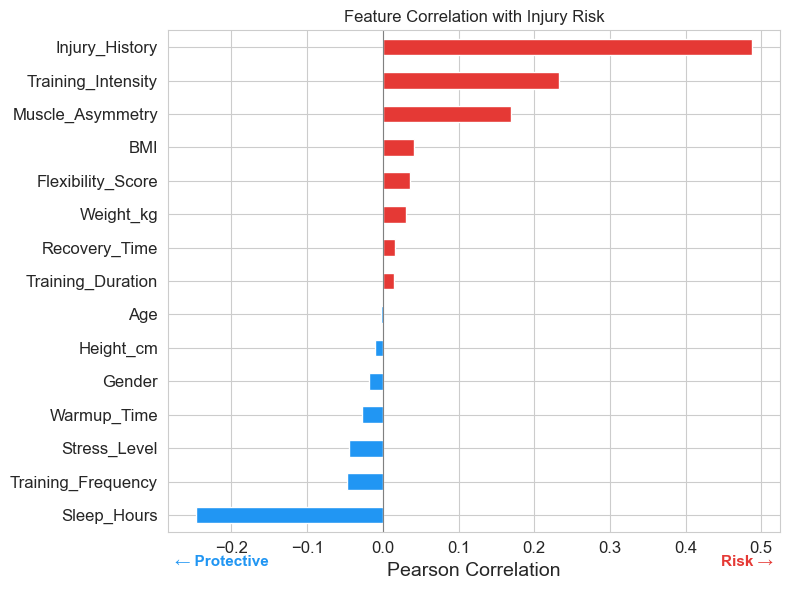

In [4]:
# Correlation of every feature with the target, sorted
corr_target = df.corr()['Injury_Risk'].drop('Injury_Risk').sort_values()

# Color bars by direction: positive = risk (red), negative = protective (blue)
bar_colors = [COLOR_TARGET[1] if c > 0 else COLOR_TARGET[0] for c in corr_target]

fig, ax = plt.subplots(figsize=(8, 6))
corr_target.plot(kind='barh', color=bar_colors, ax=ax)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_title('Feature Correlation with Injury Risk')
ax.set_xlabel('Pearson Correlation')

# Label the two sides of the axis
ax.text(ax.get_xlim()[0] + 0.01, -1.2, '← Protective', color=COLOR_TARGET[0],
        fontsize=11, fontweight='bold', va='top')
ax.text(ax.get_xlim()[1] - 0.01, -1.2, 'Risk →', color=COLOR_TARGET[1],
        fontsize=11, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

**Key takeaways:**
- `Injury_History` is by far the strongest predictor. Prior injuries are the clearest signal of future risk.
- `Sleep_Hours` is the strongest protective factor. More sleep correlates with lower injury risk.
- Training load appears interestingly strong on both sides: `Training_Intensity` is the second strongest risk factor, while `Training_Frequency` is the second strongest protective factor, followed by `Stress_Level`. Unlike history or sleep, **training load is directly controllable by coaching staff.** `Training_Duration` is notably near zero.
- `Muscle_Asymmetry` is the third strongest risk factor. It is a physical/biomechanical signal, indicating that structural imbalances independently contribute to injury.
- `Recovery_Time` and `Warmup_Time` seem to be moderate predictors.
- `Age`, `BMI`, `Height_cm` and `Weight_kg` seem to be weak predictors.

Looking at these results, four natural groups emerge. Fixed physical characteristics like height, weight and age contribute little: professional athletes tend to be homogeneous in build, so these features do not differentiate well. How an athlete trains is a much stronger signal and, uniquely, something coaching staff can directly adjust. How well an athlete recovers day-to-day — sleep, recovery time, stress — reflects behavioural and psychological readiness. Finally, physical condition assessments like muscle asymmetry, flexibility and injury history capture the current medical and biomechanical state of the body, and contain some of the strongest predictors overall.

We will use this grouping to structure the rest of the EDA, examining each group in depth:

| Group | Features |
|---|---|
| Biological markers | Age, Gender, Height_cm, Weight_kg, BMI |
| Training load | Training_Frequency, Training_Duration, Training_Intensity, Warmup_Time |
| Recovery & lifestyle | Sleep_Hours, Recovery_Time, Stress_Level |
| Physical condition | Muscle_Asymmetry, Flexibility_Score, Injury_History |

## 2.2 Feature Groups

We examine each of the four groups for distribution shape, skew and separation between safe and at-risk athletes. This tells us which features need scaling, transformation or can be dropped.

### Biological Markers

In [5]:
# Readable injury class labels for all plots in this section
df['Injury_Class'] = df['Injury_Risk'].map({0: 'Safe', 1: 'At Risk'})
palette_class = {'Safe': COLOR_TARGET[0], 'At Risk': COLOR_TARGET[1]}

/var/folders/1d/khs53zqx6vbf7rqhnxmng9rr0000gn/T/ipykernel_61520/2504417914.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Female (0)', 'Male (1)'])


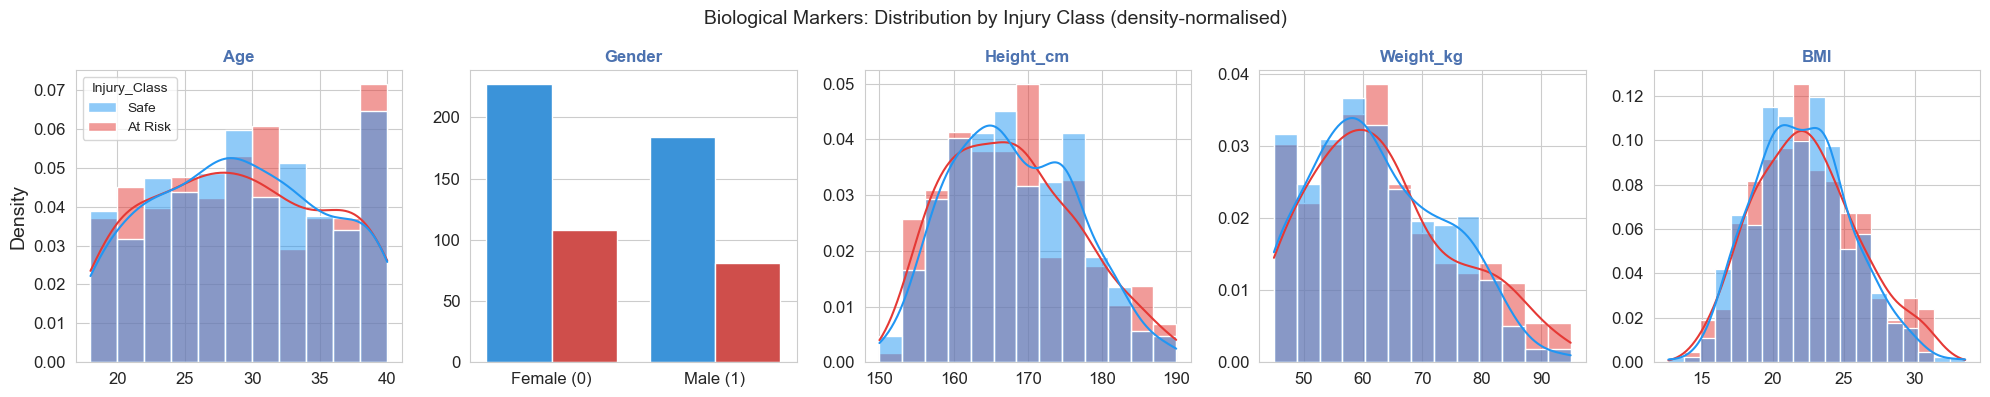

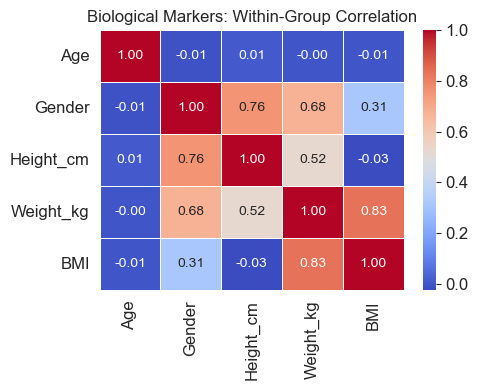

In [6]:
bio_features = ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feat in enumerate(bio_features):
    show_legend = (i == 0)
    if df[feat].nunique() <= 2:
        sns.countplot(x=feat, hue='Injury_Class', data=df,
                      palette=palette_class, ax=axes[i],
                      order=sorted(df[feat].unique()))
        axes[i].set_xticklabels(['Female (0)', 'Male (1)'])
        if not show_legend and axes[i].get_legend():
            axes[i].get_legend().remove()
    else:
        # stat='density' normalises each class so shapes are comparable despite class imbalance
        sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                     kde=True, stat='density', common_norm=False,
                     legend=show_legend, ax=axes[i])
    axes[i].set_title(feat, color=COLOR_BIO, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Biological Markers: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[bio_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Biological Markers: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- Age, Height and Weight distributions overlap almost entirely between classes. Visually, there is little separation.
- BMI shows a slight rightward shift for at-risk athletes, but the overlap is still large.
- Gender appears relatively balanced across classes, though hard to judge from counts alone given class imbalance.
- We run two statistical tests to confirm these visual impressions before deciding what to keep.

In [7]:
from scipy.stats import chi2_contingency, mannwhitneyu

safe     = df[df['Injury_Risk'] == 0]
at_risk  = df[df['Injury_Risk'] == 1]

# Chi-squared: Gender vs Injury Risk (categorical)
contingency_table = pd.crosstab(df['Gender'], df['Injury_Risk'])
chi2, p_gender, dof, _ = chi2_contingency(contingency_table)

# Mann-Whitney U: Age vs Injury Risk (continuous, non-parametric)
stat_age, p_age = mannwhitneyu(safe['Age'], at_risk['Age'], alternative='two-sided')

print("Statistical Tests: Biological Markers")
print()
print(f"Gender (Chi-squared):  chi2={chi2:.4f},  p={p_gender:.4f}  ->  {'significant' if p_gender < 0.05 else 'not significant'}")
print(f"Age    (Mann-Whitney): U={stat_age:.0f},     p={p_age:.4f}  ->  {'significant' if p_age    < 0.05 else 'not significant'}")

Statistical Tests: Biological Markers

Gender (Chi-squared):  chi2=0.1222,  p=0.7267  ->  not significant
Age    (Mann-Whitney): U=39026,     p=0.9248  ->  not significant


**What we take into feature engineering:**

Both tests confirm the visual impressions. Neither Gender nor Age is statistically associated with injury risk (p >= 0.05 for both). Combined with the near-zero correlations of Height and Weight, the biological markers group contributes very little predictive power overall.

| Feature | Decision | Reason |
|---|---|---|
| `BMI` | **Keep** | Best summary of body composition. Replaces redundant Height and Weight. |
| `Gender` | **Drop** | Not statistically significant (chi-squared, p >= 0.05). |
| `Age` | **Drop** | Not statistically significant (Mann-Whitney U, p >= 0.05). |
| `Height_cm` | **Drop** | Redundant once BMI is included. High multicollinearity. |
| `Weight_kg` | **Drop** | Redundant once BMI is included. High multicollinearity. |

### Training Load

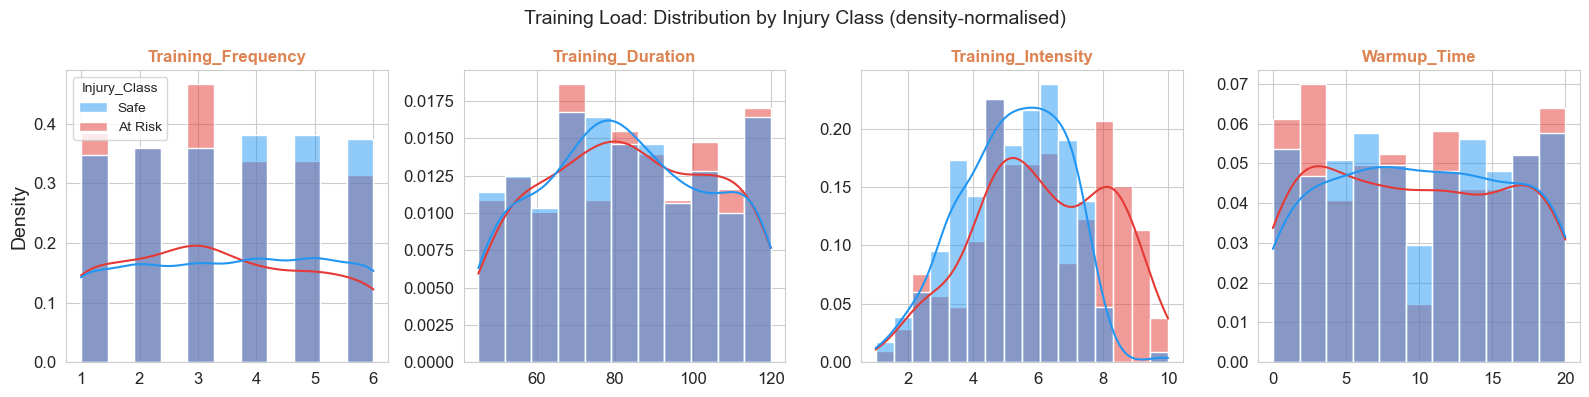

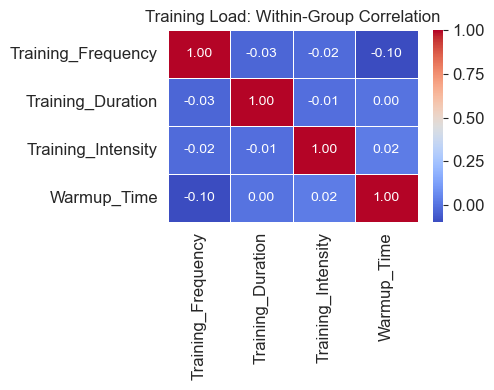

In [8]:
load_features = ['Training_Frequency', 'Training_Duration', 'Training_Intensity', 'Warmup_Time']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(load_features):
    sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                 kde=True, stat='density', common_norm=False,
                 legend=(i == 0), ax=axes[i])
    axes[i].set_title(feat, color=COLOR_LOAD, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Training Load: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[load_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Training Load: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Training_Intensity` shows the clearest separation between classes. At-risk athletes tend to train at higher intensities.
- `Training_Frequency` shifts slightly toward lower values for at-risk athletes, suggesting less frequent but harder training is a risk pattern.
- `Training_Duration` and `Warmup_Time` show heavy overlap. Their individual signal looks weak visually.
- No multicollinearity within this group (heatmap near zero). We run Mann-Whitney U tests to confirm which features are statistically significant.

In [9]:
print("Statistical Tests: Training Load (Mann-Whitney U)\n")
for feat in load_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Training Load (Mann-Whitney U)

  Training_Frequency        U=41121,  p=0.2408  ->  not significant
  Training_Duration         U=38128,  p=0.7185  ->  not significant
  Training_Intensity        U=28776,  p=0.0000  ->  significant
  Warmup_Time               U=40210,  p=0.4870  ->  not significant


**What we take into feature engineering:**

| Feature | p-value | Decision | Reason |
|---|---|---|---|
| `Training_Intensity` | 0.0000 | **Keep** | Strongest signal in the group. Clearly significant. |
| `Training_Frequency` | 0.2408 | **Drop** | Not statistically significant. |
| `Training_Duration` | 0.7185 | **Drop** | Not statistically significant. No meaningful signal. |
| `Warmup_Time` | 0.4870 | **Drop** | Not statistically significant. |

### Recovery & Lifestyle

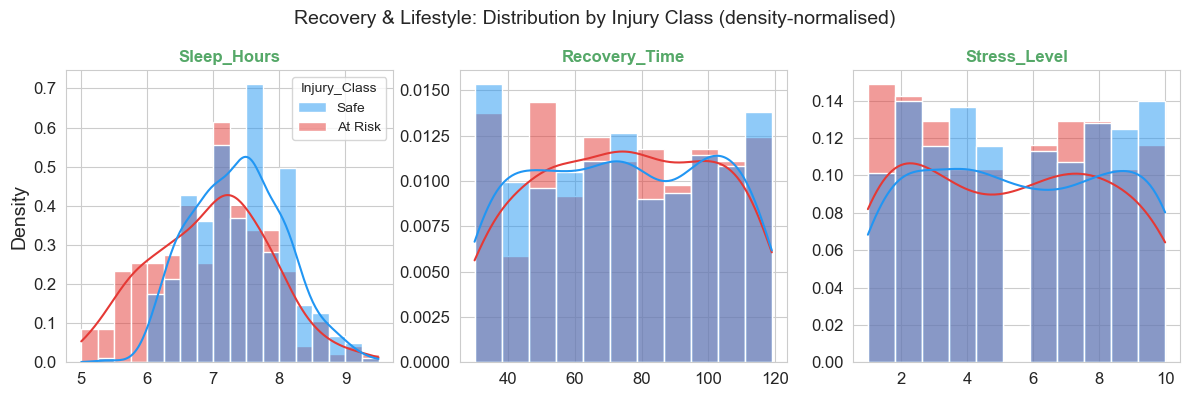

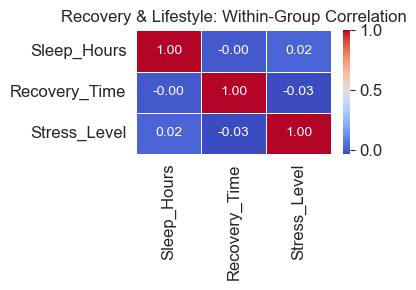

In [10]:
recovery_features = ['Sleep_Hours', 'Recovery_Time', 'Stress_Level']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, feat in enumerate(recovery_features):
    sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                 kde=True, stat='density', common_norm=False,
                 legend=(i == 0), ax=axes[i])
    axes[i].set_title(feat, color=COLOR_RECOVERY, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Recovery & Lifestyle: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(df[recovery_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Recovery & Lifestyle: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Sleep_Hours` shows a clear leftward shift for at-risk athletes. Less sleep is visually the strongest signal in this group.
- `Stress_Level` shows a slight separation but in the protective direction, which is counterintuitive.
- `Recovery_Time` shows heavy overlap between classes. Its signal looks weak visually.
- We run Mann-Whitney U tests to confirm significance before deciding what to keep.

In [11]:
print("Statistical Tests: Recovery & Lifestyle (Mann-Whitney U)\n")
for feat in recovery_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Recovery & Lifestyle (Mann-Whitney U)

  Sleep_Hours               U=49461,  p=0.0000  ->  significant
  Recovery_Time             U=38060,  p=0.6929  ->  not significant
  Stress_Level              U=41032,  p=0.2640  ->  not significant


**What we take into feature engineering:**

| Feature | p-value | Decision | Reason |
|---|---|---|---|
| `Sleep_Hours` | 0.0000 | **Keep** | Strongest protective factor in the dataset. Clearly significant. |
| `Recovery_Time` | 0.6929 | **Drop** | Not statistically significant. No meaningful signal. |
| `Stress_Level` | 0.2640 | **Drop** | Not statistically significant. |

### Physical Condition

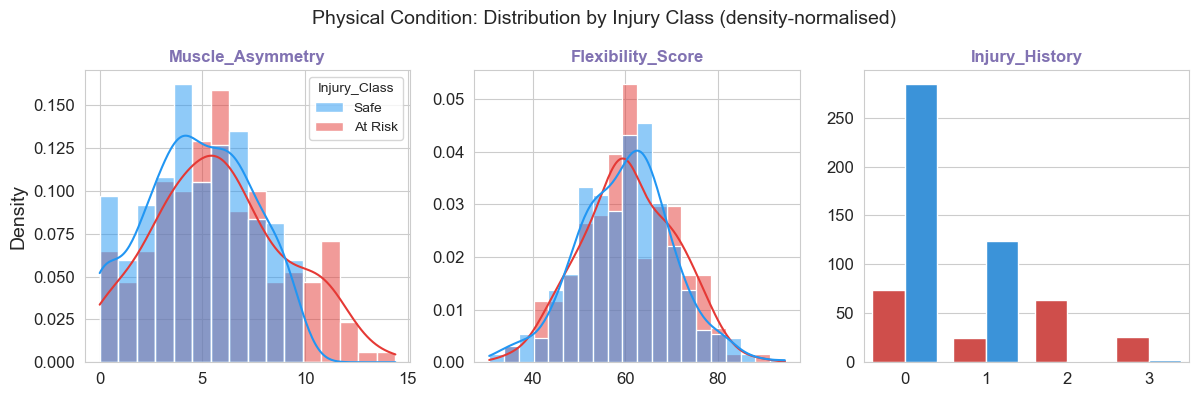

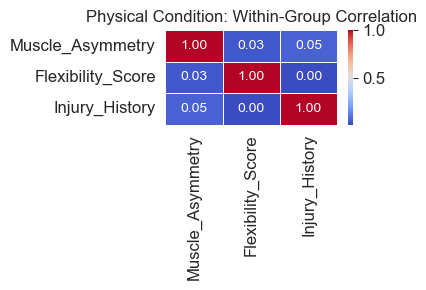

In [12]:
condition_features = ['Muscle_Asymmetry', 'Flexibility_Score', 'Injury_History']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, feat in enumerate(condition_features):
    show_legend = (i == 0)
    if df[feat].nunique() <= 5:  # treat as categorical if few unique values
        sns.countplot(x=feat, hue='Injury_Class', data=df,
                      palette=palette_class, ax=axes[i],
                      order=sorted(df[feat].unique()))
        if not show_legend and axes[i].get_legend():
            axes[i].get_legend().remove()
    else:
        sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                     kde=True, stat='density', common_norm=False,
                     legend=show_legend, ax=axes[i])
    axes[i].set_title(feat, color=COLOR_CONDITION, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Physical Condition: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(df[condition_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Physical Condition: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Injury_History` shows the starkest separation of any feature in the entire dataset. Athletes with prior injuries are heavily concentrated in the at-risk class.
- `Muscle_Asymmetry` shows a rightward shift for at-risk athletes. Structural imbalances appear to be a meaningful signal.
- `Flexibility_Score` shows considerable overlap. Its value as a standalone predictor looks limited visually.
- We run Mann-Whitney U tests to confirm which features are statistically significant.

In [13]:
print("Statistical Tests: Physical Condition (Mann-Whitney U)\n")
for feat in condition_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Physical Condition (Mann-Whitney U)

  Muscle_Asymmetry          U=32240,  p=0.0008  ->  significant
  Flexibility_Score         U=37330,  p=0.4441  ->  not significant
  Injury_History            U=21717,  p=0.0000  ->  significant


**What we take into feature engineering:**

| Feature | p-value | Decision | Reason |
|---|---|---|---|
| `Injury_History` | 0.0000 | **Keep** | Strongest predictor in the entire dataset. Clearly significant. |
| `Muscle_Asymmetry` | 0.0008 | **Keep** | Statistically significant. Independent biomechanical risk signal. |
| `Flexibility_Score` | 0.4441 | **Drop** | Not statistically significant. |

## 2.3 Cross-Group Interactions

A full correlation matrix across all features. This reveals multicollinearity between groups and hints at interaction features worth engineering (e.g. high training intensity combined with low sleep).

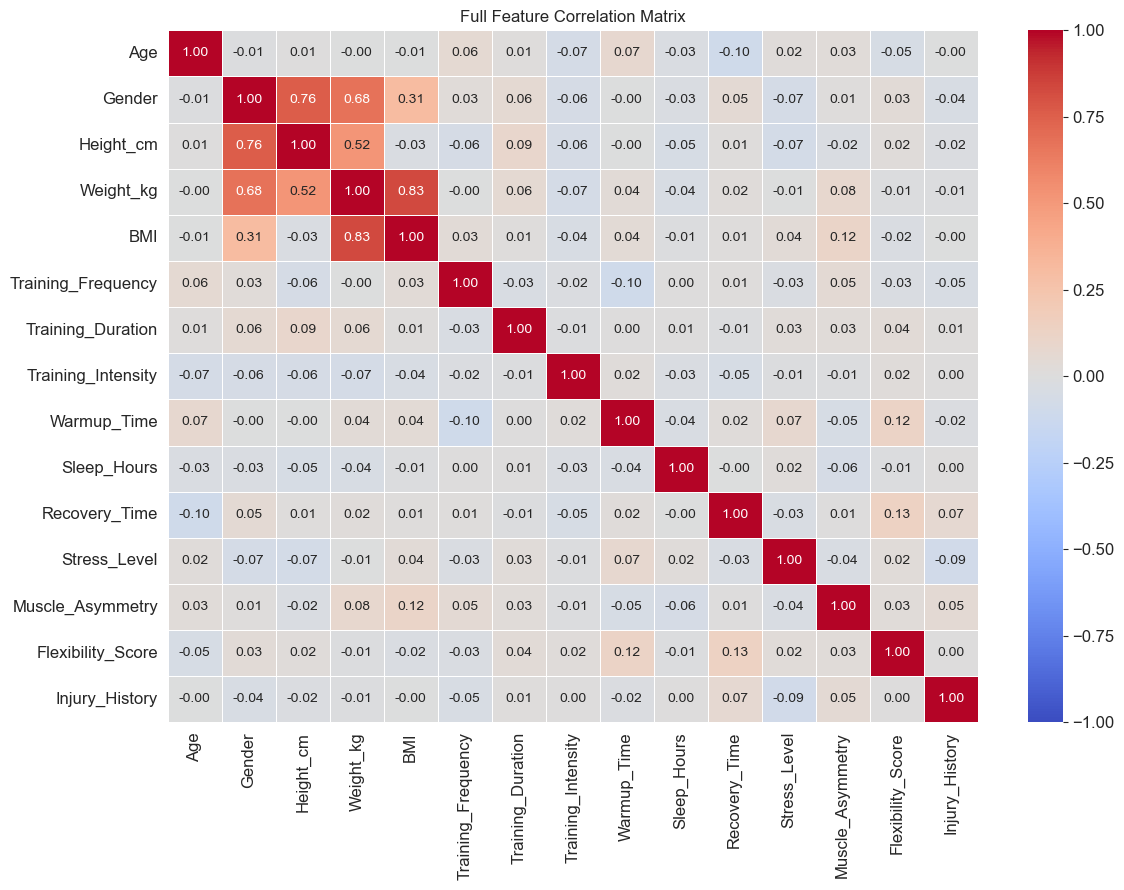

In [14]:
# Full correlation matrix, ordered by feature group for readability
all_features = bio_features + load_features + recovery_features + condition_features
corr_full = df[all_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Full Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Cross-group observations:**
- `Height_cm`, `Weight_kg` and `BMI` are highly correlated with each other (as expected). Keeping all three would introduce redundancy. BMI will be retained as it captures both in a single meaningful ratio.
- No strong correlations exist between training load features and recovery features, which suggests they capture independent aspects of athlete condition.
- The combination of high `Training_Intensity` and low `Sleep_Hours` is worth considering as an engineered interaction feature in Section 3.

## 2.4 EDA Summary: Decisions Going into Feature Engineering

Based on visual inspection and statistical tests (Mann-Whitney U / chi-squared), we identified a core set of significant features and a set of candidates for dropping.

**Confirmed features:** `BMI`, `Training_Intensity`, `Sleep_Hours`, `Injury_History`, `Muscle_Asymmetry`

**Candidates for dropping:**

| Feature | Reason |
|---|---|
| `Height_cm`, `Weight_kg` | Redundant with BMI. High multicollinearity. |
| `Age` | Not significant (Mann-Whitney U, p >= 0.05) |
| `Gender` | Not significant (chi-squared, p >= 0.05) |
| `Training_Frequency` | Not significant (p=0.24) |
| `Training_Duration` | Not significant (p=0.72) |
| `Warmup_Time` | Not significant (p=0.49) |
| `Recovery_Time` | Not significant (p=0.69) |
| `Stress_Level` | Not significant (p=0.26) |
| `Flexibility_Score` | Not significant (p=0.44) |

Statistical significance tests features individually and does not capture potential interactions or combined effects. We start modelling with the confirmed features only, but may reintroduce candidates if model performance suggests they add value.

**Additional steps in Section 3:**
- Apply `StandardScaler` to all continuous features (different scales and units)
- Engineer interaction feature: `Training_Intensity` x `Sleep_Hours`
- Train/test split: 80/20, stratified on target, `random_state=42`